In [39]:
import requests
import json
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
API_KEY = '46f52586'

In [190]:
def generate_poster(movie_title, exact = True):
        
        base_url_omdb = 'http://www.omdbapi.com'
        base_url_img = 'http://img.omdbapi.com'
        
        params = {
                't': movie_title,
                'apikey': API_KEY,
                's': movie_title
        }
        
        if not exact:
                del params['s']
                response = requests.get(base_url, params=params).json()
                id = response['imdbID']
                imdb_poster_url = response['Poster']
                print(imdb_poster_url)
        else:
                del params['t'] 
                id = requests.get(base_url, params=params).json()['Search'][0]['imdbID']
        
        print(id)

        params_poster = {
                        'i': id,
                        'h': 300,
                        'apikey': API_KEY
        }

        response = requests.get(base_url_img, params=params_poster)
        print(response.url)

        try:
                poster = BytesIO(response.content)
                img = mpimg.imread(poster, format="jpeg")
        except:
                print('Finding IMDB Poster')
                poster = BytesIO(requests.get(imdb_poster_url).content)
                img = mpimg.imread(poster, format="jpeg")

        plt.imshow(img)
        plt.axis("off")
        plt.tight_layout(pad = 0)
        plt.margins(0)
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        plt.show()

https://m.media-amazon.com/images/M/MV5BMjM1OTMxNzUyM15BMl5BanBnXkFtZTgwNjYzMTIzOTE@._V1_SX300.jpg
tt1386697
http://img.omdbapi.com/?i=tt1386697&h=300&apikey=46f52586
Finding IMDB Poster


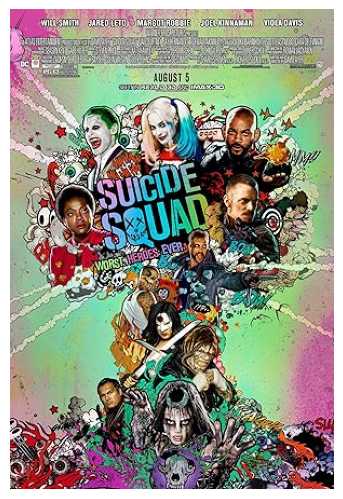

In [191]:
title = "Suicide Squad"

generate_poster(title, exact = False)